In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
games = pd.read_csv("/content/games.csv")
sales = pd.read_csv("/content/vgsales.csv")

print(games.head())
print(sales.head())

   Unnamed: 0                                    Title  Release Date  \
0           0                               Elden Ring  Feb 25, 2022   
1           1                                    Hades  Dec 10, 2019   
2           2  The Legend of Zelda: Breath of the Wild  Mar 03, 2017   
3           3                                Undertale  Sep 15, 2015   
4           4                            Hollow Knight  Feb 24, 2017   

                                                Team  Rating Times Listed  \
0     ['Bandai Namco Entertainment', 'FromSoftware']     4.5         3.9K   
1                               ['Supergiant Games']     4.3         2.9K   
2  ['Nintendo', 'Nintendo EPD Production Group No...     4.4         4.3K   
3                                 ['tobyfox', '8-4']     4.2         3.5K   
4                                    ['Team Cherry']     4.4           3K   

  Number of Reviews                                             Genres  \
0              3.9K           

In [4]:
# Remove duplicates
games.drop_duplicates(inplace=True)
sales.drop_duplicates(inplace=True)

# Handle missing values
games.fillna(0, inplace=True)
sales.fillna(0, inplace=True)

# Rename columns for merging
sales.rename(columns={"Name": "Title"}, inplace=True)

# Normalize text
games['Genres'] = games['Genres'].str.lower()
sales['Genre'] = sales['Genre'].str.lower()

In [6]:
merged = pd.merge(games, sales, on=["Title"], how="inner")

print(merged.head())

   Unnamed: 0      Title  Release Date                Team  Rating  \
0           5  Minecraft  Nov 18, 2011  ['Mojang Studios']     4.3   
1           5  Minecraft  Nov 18, 2011  ['Mojang Studios']     4.3   
2           5  Minecraft  Nov 18, 2011  ['Mojang Studios']     4.3   
3           5  Minecraft  Nov 18, 2011  ['Mojang Studios']     4.3   
4           5  Minecraft  Nov 18, 2011  ['Mojang Studios']     4.3   

  Times Listed Number of Reviews                      Genres  \
0         2.3K              2.3K  ['adventure', 'simulator']   
1         2.3K              2.3K  ['adventure', 'simulator']   
2         2.3K              2.3K  ['adventure', 'simulator']   
3         2.3K              2.3K  ['adventure', 'simulator']   
4         2.3K              2.3K  ['adventure', 'simulator']   

                                             Summary  \
0  Minecraft focuses on allowing the player to ex...   
1  Minecraft focuses on allowing the player to ex...   
2  Minecraft focuses on al

In [7]:
top_rated = merged[['Title','Rating']].sort_values(by='Rating', ascending=False).head(10)
print(top_rated)

                                Title  Rating
913   Metal Gear Solid 3: Subsistence     4.6
315                        Bloodborne     4.5
54                     Chrono Trigger     4.5
55                     Chrono Trigger     4.5
1253   Silent Hill 2: Restless Dreams     4.5
794   Metal Gear Solid 3: Snake Eater     4.5
756                    Chrono Trigger     4.5
757                    Chrono Trigger     4.5
120   Metal Gear Solid 3: Snake Eater     4.5
94                           Mother 3     4.5


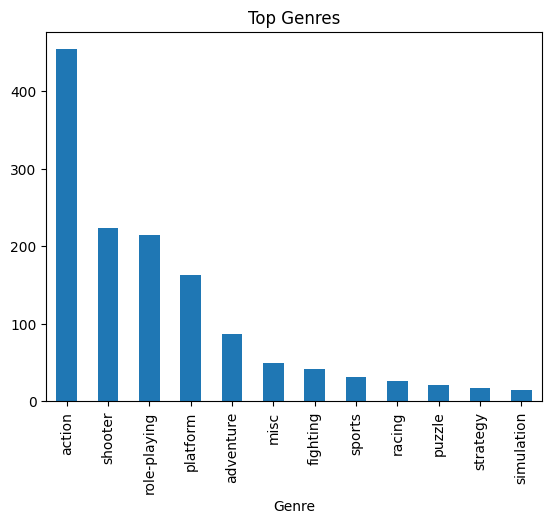

In [8]:
genre_count = merged['Genre'].value_counts()

plt.figure()
genre_count.plot(kind='bar')
plt.title("Top Genres")
plt.show()

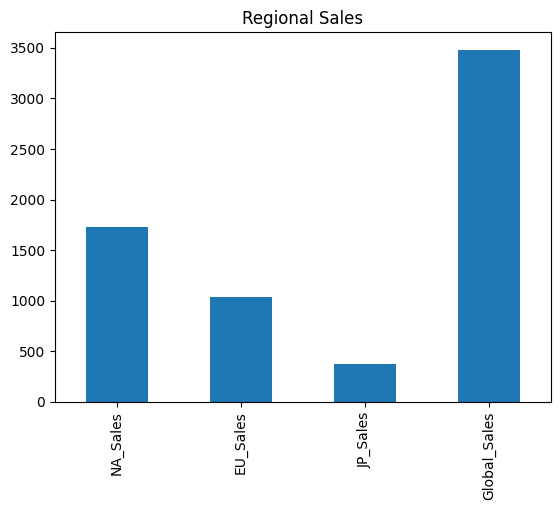

In [9]:
region_sales = merged[['NA_Sales','EU_Sales','JP_Sales','Global_Sales']].sum()

region_sales.plot(kind='bar')
plt.title("Regional Sales")
plt.show()

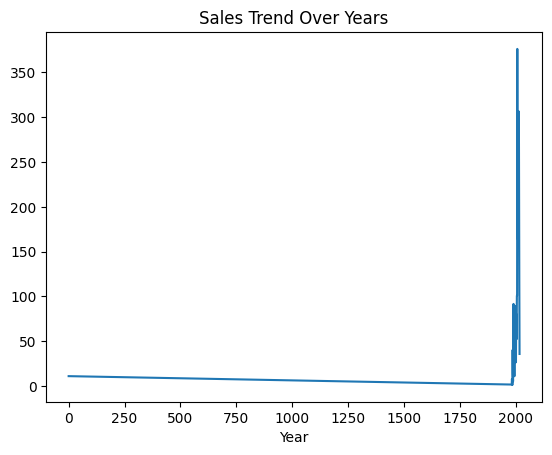

In [10]:
yearly_sales = merged.groupby('Year')['Global_Sales'].sum()

yearly_sales.plot()
plt.title("Sales Trend Over Years")
plt.show()

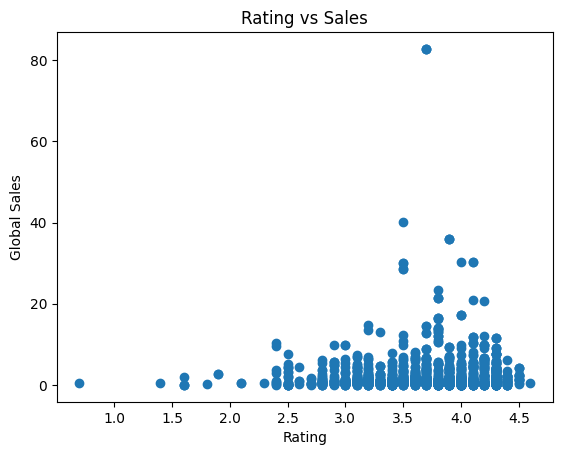

In [11]:
plt.scatter(merged['Rating'], merged['Global_Sales'])
plt.xlabel("Rating")
plt.ylabel("Global Sales")
plt.title("Rating vs Sales")
plt.show()

In [12]:
print("Total Sales:", merged['Global_Sales'].sum())
print("Average Rating:", merged['Rating'].mean())
print("Top Platform:", merged['Platform'].value_counts().idxmax())

Total Sales: 3480.1
Average Rating: 3.6674851190476194
Top Platform: PS3


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Function to convert 'K' strings to numerical values
def convert_k_to_numeric(value):
    if isinstance(value, str):
        if 'K' in value:
            return float(value.replace('K', '')) * 1000
    return float(value)

# Apply the conversion to 'Wishlist' and 'Plays' columns
merged['Wishlist'] = merged['Wishlist'].apply(convert_k_to_numeric)
merged['Plays'] = merged['Plays'].apply(convert_k_to_numeric)

# Features
X = merged[['Rating','Wishlist','Plays']]
y = merged['Global_Sales']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

print("Sample Predictions:")
print(pred[:5])

Sample Predictions:
[3.02948956 4.68541448 1.94348606 3.93881543 0.05097118]


In [16]:
top_games = merged[['Title','Rating','Global_Sales']].sort_values(
    by=['Rating','Global_Sales'], ascending=False
).head(10)

print("Top 10 Games:")
print(top_games)

Top 10 Games:
                               Title  Rating  Global_Sales
913  Metal Gear Solid 3: Subsistence     4.6          0.55
120  Metal Gear Solid 3: Snake Eater     4.5          4.23
393  Metal Gear Solid 3: Snake Eater     4.5          4.23
794  Metal Gear Solid 3: Snake Eater     4.5          4.23
10                        Bloodborne     4.5          2.38
315                       Bloodborne     4.5          2.38
704                       Bloodborne     4.5          2.38
54                    Chrono Trigger     4.5          2.31
756                   Chrono Trigger     4.5          2.31
55                    Chrono Trigger     4.5          1.47


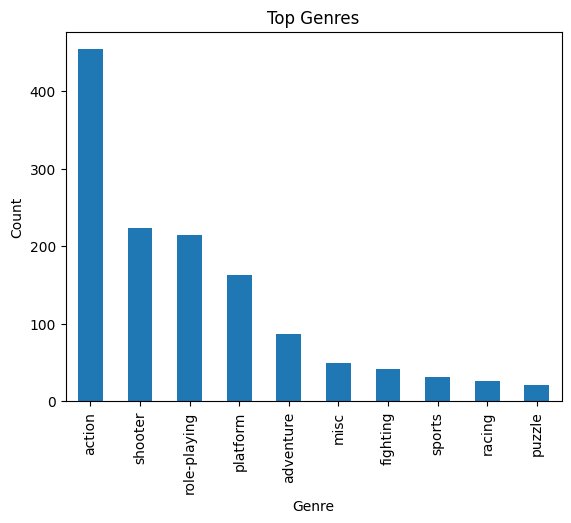

In [18]:
genre_count = merged['Genre'].value_counts().head(10)

plt.figure()
genre_count.plot(kind='bar')
plt.title("Top Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

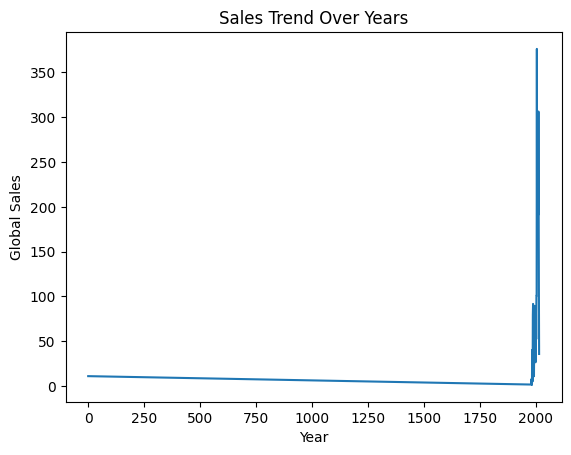

In [20]:
yearly_sales = merged.groupby('Year')['Global_Sales'].sum()

plt.figure()
yearly_sales.plot()
plt.title("Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Global Sales")
plt.show()

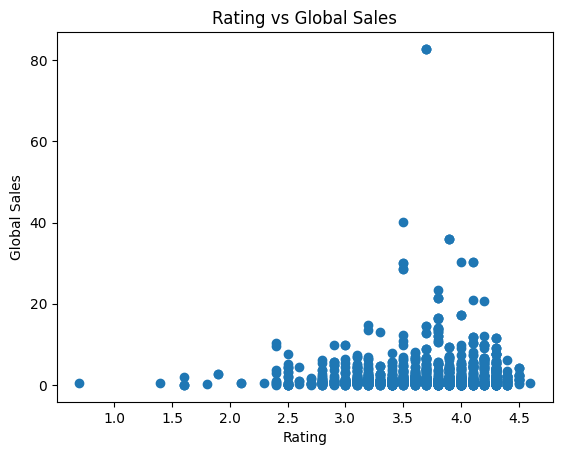

In [21]:
plt.figure()
plt.scatter(merged['Rating'], merged['Global_Sales'])
plt.title("Rating vs Global Sales")
plt.xlabel("Rating")
plt.ylabel("Global Sales")
plt.show()

In [23]:
print("Total Global Sales:", merged['Global_Sales'].sum())
print("Average Rating:", merged['Rating'].mean())
print("Top Platform:", merged['Platform'].value_counts().idxmax())

Total Global Sales: 3480.1
Average Rating: 3.6674851190476194
Top Platform: PS3


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features
X = merged[['Rating','Wishlist','Plays']]
y = merged['Global_Sales']

# Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
predictions = model.predict(X_test)

print("Sample Predictions:")
print(predictions[:10])

Sample Predictions:
[1.81725098 0.86101958 2.13158414 3.86542648 2.68591133 1.84929272
 1.21325508 1.42859525 1.24407023 3.09787196]
